In [ ]:
TASK 1 – Netflix Data Cleaning & Preprocessing

In [12]:
import zipfile

with zipfile.ZipFile("netflix_titles.csv.zip", "r") as zip_ref:
    zip_ref.extractall(".")

print("Extracted successfully")

Extracted successfully


In [13]:
import os
print(os.listdir("."))

['Intro.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'netflix_titles.csv', 'netflix_titles.csv.zip', 'r.ipynb', 'Lorenz.ipynb', 'Mandelbrot.ipynb', 'sqlite.ipynb', 'cpp.ipynb', 'cpp-third-party-libs.ipynb', 'cpp-tiny-ray-tracer.ipynb']


In [14]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [16]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [17]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["date_added"] = df["date_added"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [18]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [19]:
df["country"] = df["country"].str.strip()
df["rating"] = df["rating"].str.strip()
df["type"] = df["type"].str.strip()

print("Formatting standardized successfully")

Formatting standardized successfully


In [20]:
df.to_csv("netflix_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
TASK 2 – Content Type Analysis Dashboard

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_cleaned.csv")

print(df["type"].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


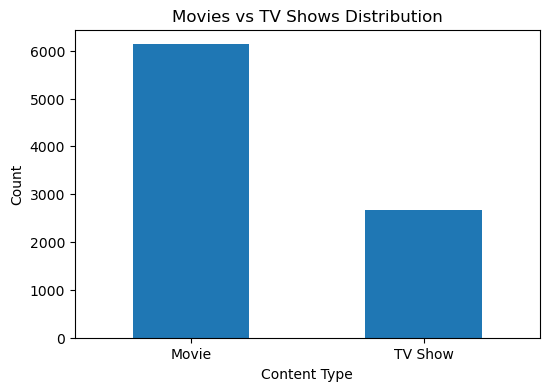

In [23]:
# Content Type Distribution

type_counts = df["type"].value_counts()

plt.figure(figsize=(6, 4))
type_counts.plot(kind="bar")

plt.title("Movies vs TV Shows Distribution")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [24]:
# Calculate proportions

proportions = df["type"].value_counts(normalize=True) * 100

print(proportions.round(2))

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


In [ ]:
# TASK 2 – Findings

In [30]:
print("TASK 2 – Findings")
print()
print("- Movies have a higher count than TV Shows.")
print("- Movies represent around 70% of the content.")
print("- TV Shows represent around 30% of the content.")
print("- The dataset contains significantly more Movies than TV Shows.")

TASK 2 – Findings

- Movies have a higher count than TV Shows.
- Movies represent around 70% of the content.
- TV Shows represent around 30% of the content.
- The dataset contains significantly more Movies than TV Shows.


In [ ]:
TASK 3 – Country-Wise Netflix Content Analysis

In [32]:
print(df["country"].head(10))

0                                        United States
1                                         South Africa
2                                              Unknown
3                                              Unknown
4                                                India
5                                              Unknown
6                                              Unknown
7    United States, Ghana, Burkina Faso, United Kin...
8                                       United Kingdom
9                                        United States
Name: country, dtype: str


In [33]:
# Clean country information

df["country"] = df["country"].fillna("Unknown")

df["country"] = df["country"].str.split(", ")

df_exploded = df.explode("country")

print(df_exploded["country"].head(10))

0    United States
1     South Africa
2          Unknown
3          Unknown
4            India
5          Unknown
6          Unknown
7    United States
7            Ghana
7     Burkina Faso
Name: country, dtype: str


In [34]:
# Calculate content count by country

country_counts = df_exploded["country"].value_counts()

print(country_counts.head(10))

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


In [35]:
# Top 10 Content-Producing Countries

top_countries = country_counts.head(10)

print(top_countries)

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


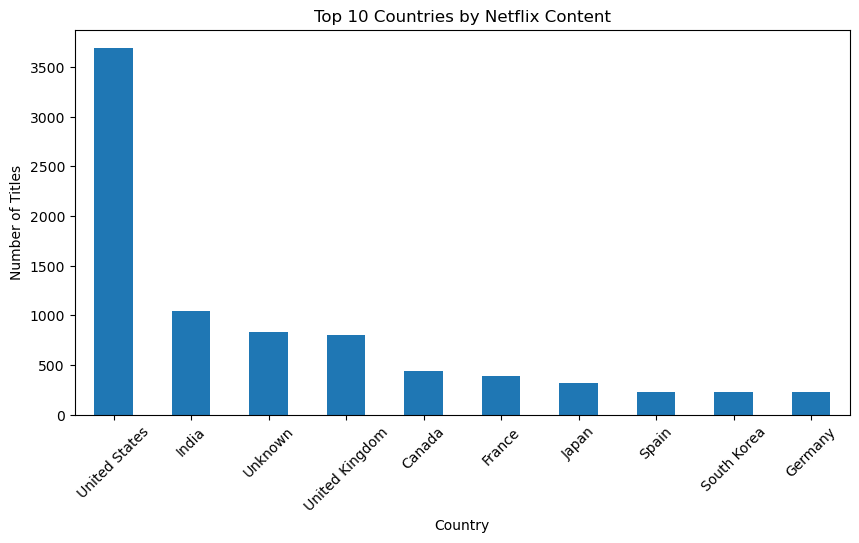

In [36]:
# Top 10 Countries Chart

plt.figure(figsize=(10, 5))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [37]:
# Task 3 – Business Insights

print("TASK 3 – Business Insights")
print()
print("- The United States produces the highest amount of Netflix content.")
print("- India is one of the major content-producing countries.")
print("- Netflix content is produced across many countries.")
print("- The country analysis shows Netflix has a global content presence.")

TASK 3 – Business Insights

- The United States produces the highest amount of Netflix content.
- India is one of the major content-producing countries.
- Netflix content is produced across many countries.
- The country analysis shows Netflix has a global content presence.


In [ ]:
TASK 4 – Trend Analysis by Release Year

In [38]:
# Organize content by release year

year_counts = df["release_year"].value_counts().sort_index()

print(year_counts)

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


In [39]:
# Identify growth and decline

yearly_change = year_counts.diff()

print(yearly_change.tail(10))

release_year
2012     52.0
2013     51.0
2014     64.0
2015    208.0
2016    342.0
2017    130.0
2018    115.0
2019   -117.0
2020    -77.0
2021   -361.0
Name: count, dtype: float64


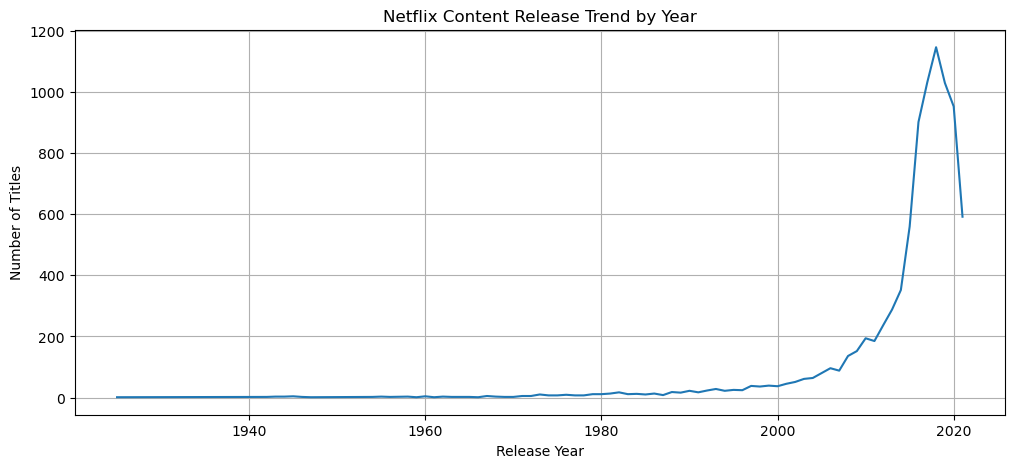

In [40]:
# Trend Visualization

plt.figure(figsize=(12, 5))

year_counts.plot(kind="line")

plt.title("Netflix Content Release Trend by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid()
plt.show()

In [41]:
# Task 4 – Business Insights

print("TASK 4 – Business Insights")
print()
print("- Netflix content production increased significantly over the years.")
print("- Content releases reached a peak around 2018.")
print("- Content production declined after 2019.")
print("- The recent decline may indicate changes in content production or dataset coverage.")

TASK 4 – Business Insights

- Netflix content production increased significantly over the years.
- Content releases reached a peak around 2018.
- Content production declined after 2019.
- The recent decline may indicate changes in content production or dataset coverage.


In [ ]:
TASK 5 – Content Rating & Genre Analysis

In [42]:
# Step 1 – Analyze Rating Categories

print(df["rating"].value_counts())

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [43]:
# Analyze Genres

print(df["listed_in"].value_counts().head(10))

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


In [44]:
# Compare Ratings Across Content Types

rating_type = pd.crosstab(df["rating"], df["type"])

print(rating_type)

type      Movie  TV Show
rating                  
66 min        1        0
74 min        1        0
84 min        1        0
G            41        0
NC-17         3        0
NR           75        5
PG          287        0
PG-13       490        0
R           797        2
TV-14      1427      733
TV-G        126       94
TV-MA      2062     1145
TV-PG       540      323
TV-Y        131      176
TV-Y7       139      195
TV-Y7-FV      5        1
UR            3        0
Unknown       2        2


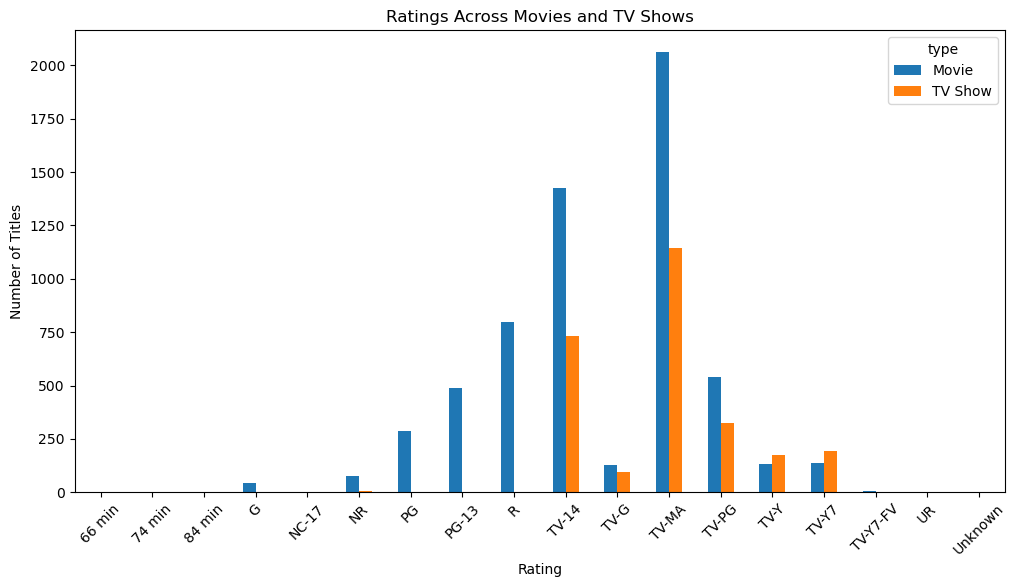

In [45]:
# Rating Comparison Chart

rating_type.plot(kind="bar", figsize=(12, 6))

plt.title("Ratings Across Movies and TV Shows")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [46]:
# Task 5 – Audience Insights

print("TASK 5 – Audience Insights")
print()
print("- Netflix content covers a wide range of audience age groups.")
print("- Mature ratings are common, showing strong content for adult audiences.")
print("- Movies and TV Shows have different rating distributions.")
print("- The genre analysis shows Netflix offers diverse content categories.")
print("- Rating and genre patterns can help Netflix understand audience preferences.")

TASK 5 – Audience Insights

- Netflix content covers a wide range of audience age groups.
- Mature ratings are common, showing strong content for adult audiences.
- Movies and TV Shows have different rating distributions.
- The genre analysis shows Netflix offers diverse content categories.
- Rating and genre patterns can help Netflix understand audience preferences.


In [ ]:
TASK 6 – Netflix Business Insights Report

In [47]:
# Step 1 – Exploratory Data Analysis

print("Dataset Shape:", df.shape)
print()
print("Column Names:")
print(df.columns.tolist())
print()
print("Missing Values:")
print(df.isnull().sum())
print()
print("Dataset Information:")
print(df.info())

Dataset Shape: (8807, 12)

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Missing Values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   str   
 1   type          8807 non-null   str   
 2   title         8807 non-null   str   
 3   director      8807 non-null   str   
 4   cast          8807 non-null   str   
 5   country       8807 non-null   object
 6   date_added    8807 non-null   str   
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   

In [48]:
# Step 2 – Key Content Trends and Patterns

print("Total Movies:", (df["type"] == "Movie").sum())
print("Total TV Shows:", (df["type"] == "TV Show").sum())
print()

print("Top 5 Countries:")
print(df_exploded["country"].value_counts().head(5))
print()

print("Top 5 Release Years:")
print(df["release_year"].value_counts().head(5))
print()

print("Top 5 Ratings:")
print(df["rating"].value_counts().head(5))
print()

print("Top 5 Genres:")
print(df["listed_in"].value_counts().head(5))

Total Movies: 6131
Total TV Shows: 2676

Top 5 Countries:
country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
Name: count, dtype: int64

Top 5 Release Years:
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
Name: count, dtype: int64

Top 5 Ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

Top 5 Genres:
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Name: count, dtype: int64


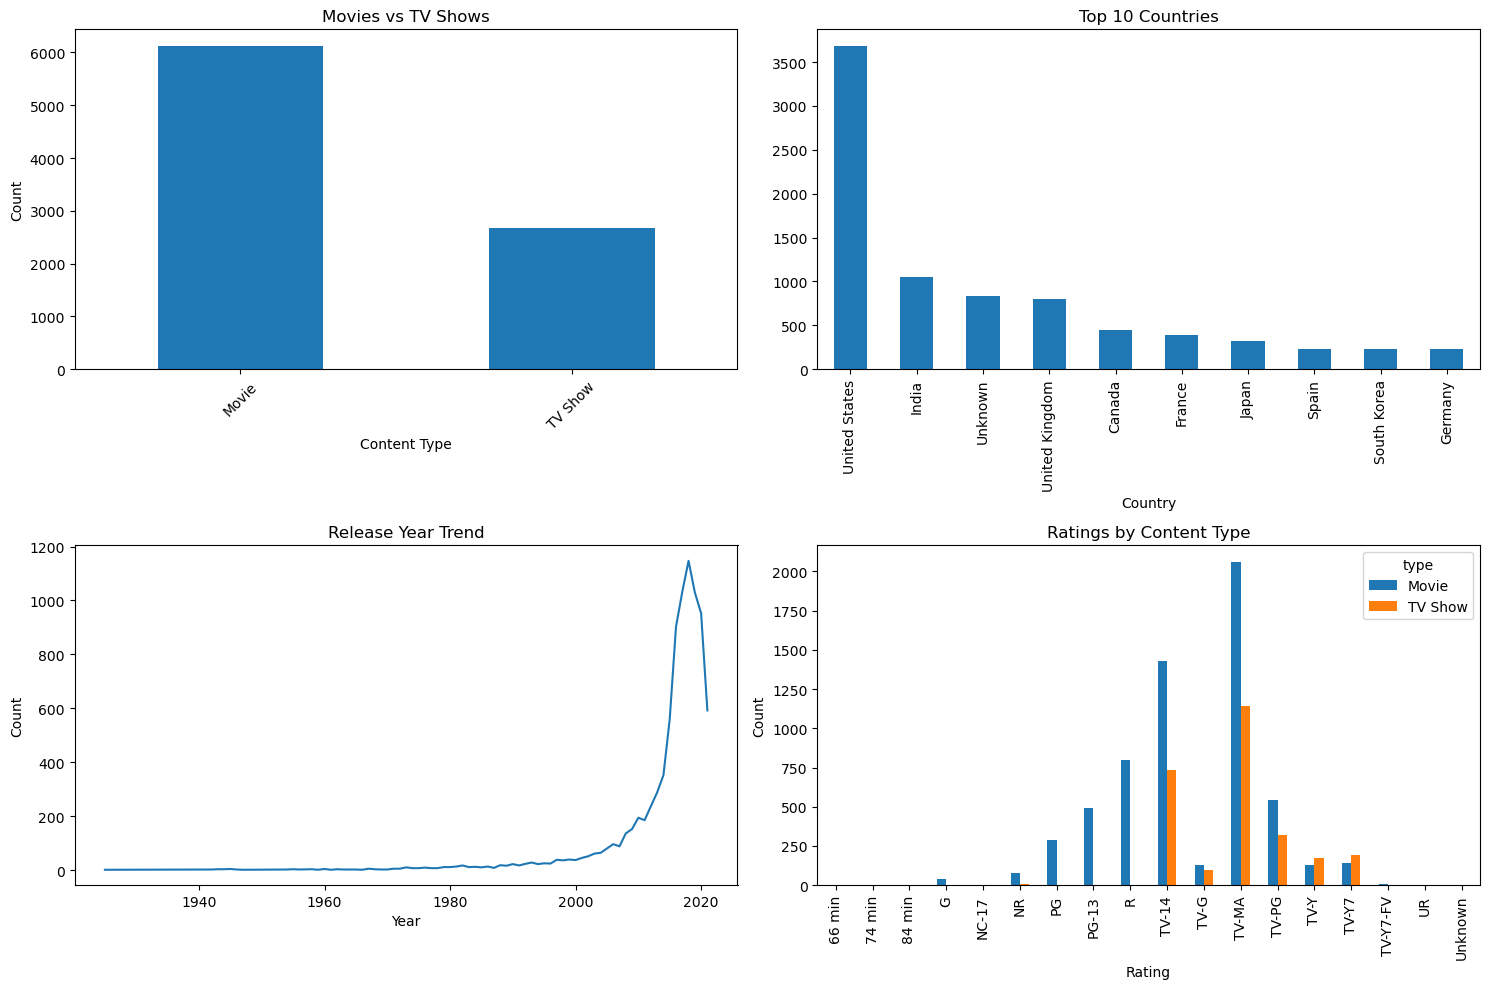

In [49]:
# Step 3 – Multiple Visual Dashboards

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Movies vs TV Shows
type_counts.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Movies vs TV Shows")
axes[0, 0].set_xlabel("Content Type")
axes[0, 0].set_ylabel("Count")

# 2. Top 10 Countries
top_countries.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Top 10 Countries")
axes[0, 1].set_xlabel("Country")
axes[0, 0].tick_params(axis="x", rotation=45)

# 3. Release Year Trend
year_counts.plot(kind="line", ax=axes[1, 0])
axes[1, 0].set_title("Release Year Trend")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Count")

# 4. Ratings by Content Type
rating_type.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Ratings by Content Type")
axes[1, 1].set_xlabel("Rating")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [50]:
# Step 4 – Actionable Business Insights

print("TASK 6 – Actionable Business Insights")
print()

print("1. Content Strategy:")
print("Netflix has more Movies than TV Shows, so content strategy can focus on maintaining a balanced mix.")

print()

print("2. Global Expansion:")
print("The United States and India are major content-producing countries, showing strong opportunities for regional content.")

print()

print("3. Content Growth:")
print("Netflix content production increased significantly in recent years, indicating strong expansion of the content library.")

print()

print("4. Audience Targeting:")
print("The rating and genre analysis shows that Netflix serves different audience segments.")

print()

print("5. Business Recommendation:")
print("Netflix can use country, genre, rating and release-year trends to plan future content investments.")

TASK 6 – Actionable Business Insights

1. Content Strategy:
Netflix has more Movies than TV Shows, so content strategy can focus on maintaining a balanced mix.

2. Global Expansion:
The United States and India are major content-producing countries, showing strong opportunities for regional content.

3. Content Growth:
Netflix content production increased significantly in recent years, indicating strong expansion of the content library.

4. Audience Targeting:
The rating and genre analysis shows that Netflix serves different audience segments.

5. Business Recommendation:
Netflix can use country, genre, rating and release-year trends to plan future content investments.


In [51]:
# Step 5 – Final Analytical Report

print("=" * 50)
print("NETFLIX BUSINESS INSIGHTS REPORT")
print("=" * 50)

print("\n1. CONTENT OVERVIEW")
print("Movies are the largest content type in the Netflix dataset.")

print("\n2. COUNTRY ANALYSIS")
print("The United States is the leading content-producing country.")
print("India is also one of the major content-producing countries.")

print("\n3. RELEASE YEAR TREND")
print("Netflix content production increased significantly over time.")
print("Content releases reached a high level around 2018 and declined afterwards.")

print("\n4. RATING & GENRE ANALYSIS")
print("Netflix offers content across different ratings and genres.")
print("This indicates that Netflix targets a wide range of audience segments.")

print("\n5. KEY BUSINESS INSIGHTS")
print("• Netflix has a strong global content presence.")
print("• Movies form the majority of the content library.")
print("• Regional content is important for global expansion.")
print("• Genre and rating trends can support audience targeting.")

print("\n6. RECOMMENDATIONS")
print("• Invest in high-performing genres.")
print("• Continue developing regional content.")
print("• Maintain a balanced Movies and TV Shows strategy.")
print("• Use data-driven insights for future content planning.")

print("\n" + "=" * 50)
print("END OF REPORT")
print("=" * 50)

NETFLIX BUSINESS INSIGHTS REPORT

1. CONTENT OVERVIEW
Movies are the largest content type in the Netflix dataset.

2. COUNTRY ANALYSIS
The United States is the leading content-producing country.
India is also one of the major content-producing countries.

3. RELEASE YEAR TREND
Netflix content production increased significantly over time.
Content releases reached a high level around 2018 and declined afterwards.

4. RATING & GENRE ANALYSIS
Netflix offers content across different ratings and genres.
This indicates that Netflix targets a wide range of audience segments.

5. KEY BUSINESS INSIGHTS
• Netflix has a strong global content presence.
• Movies form the majority of the content library.
• Regional content is important for global expansion.
• Genre and rating trends can support audience targeting.

6. RECOMMENDATIONS
• Invest in high-performing genres.
• Continue developing regional content.
• Maintain a balanced Movies and TV Shows strategy.
• Use data-driven insights for future con